In [7]:
# Import packages
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read in the data
df = pd.read_excel('Maha_Spare_Data.xlsx', header=0)
df_alternate = pd.read_excel('AlternatePartNumbers.xlsx', header=0)

# print(df.columns)



In [8]:
df['PO date'] = pd.to_datetime(df['PO date'], dayfirst=True)
df['Bill. Date'] = pd.to_datetime(df['Bill. Date'], dayfirst=True)

Plants = df[' Plnt'].dropna().unique()
print(df[' Plnt'].dropna().unique())

[5502. 5505. 5513.]


In [9]:
df.columns = df.columns.str.strip()

df['Plnt'] = pd.to_numeric(df['Plnt'], errors='coerce')
df_5502 = df.loc[df['Plnt'] == 5502]
df_5505 = df.loc[df['Plnt'] == 5505]
df_5513 = df.loc[df['Plnt'] == 5513]


In [10]:
# print(df_5502[['PO date', 'City', 'Material']])
print(df_5502['Material'].unique())
materials = df_5502['Material'].dropna().unique()
# pd.DataFrame(materials, columns=['Material']).to_excel('materials_5502.xlsx', index=False)

['UF211ELPSW040' 'UF921OTKIT100' 'UF321MXDRM021' ... 'DV911PPBYH010'
 'UF321MXAFD870' 'TL321ECPCB201']


In [47]:
print(df_5502.columns)

Index(['Plnt', 'BillT', 'Dv', 'DChl', 'PO number', 'PO date', 'City',
       'Bill. Date', 'Bill.Doc.', 'Sold-to pt', 'Ship-To-Party-Name',
       'Ship-to', 'Sold Party Name', 'Material', 'Material Description',
       'Matl Group', 'Inv. Qty', 'Dealer Pri', 'Basic Rate', 'Net value',
       'Tax', 'Gross Val', 'Bill Time', 'Delivery', 'PO number.1'],
      dtype='str')


In [9]:
df_ibm = pd.read_excel('ibm_results.xlsx', header=0)
materials_ibm = sorted(df_ibm['Material Code'].unique())

In [11]:
df_alternate.columns= df_alternate.columns.str.strip()

df_alternate_clean = df_alternate.dropna(subset=['Master Mat', 'Substitute'])

df_alternate_clean = df_alternate_clean[['Master Mat', 'Substitute']]

In [12]:
# Clean column names
df_5502.columns = df_5502.columns.str.strip()

# Ensure datetime
df_5502['PO date'] = pd.to_datetime(df_5502['PO date'], errors='coerce')

# Drop bad rows
df_clean = df_5502.dropna(subset=['PO date', 'Material', 'Inv. Qty'])

df_clean = df_clean[['PO date', 'Material', 'Inv. Qty']]

materials = sorted(df_clean['Material'].unique())
print(f"The number of unique materials is {len(materials)}")

The number of unique materials is 2240


In [13]:
pd.DataFrame(df_clean).to_excel('5502_cleaned.xlsx', index=False)

In [14]:
from collections import defaultdict
import time

plant_mat_5502 = defaultdict(list)


for _, row in df_clean.iterrows():  
    mat = row['Material']  
    
    # print(f"Material = {mat}")
    # time.sleep(10)    
    if mat in df_alternate_clean["Substitute"] :
        index = df_alternate_clean["Substitute"].index(mat)
        master_mat = df_alternate_clean["Master Mat"][index]
        
        if master_mat not in plant_mat_5502 :
            plant_mat_5502[master_mat] = []
        
        plant_mat_5502[master_mat].append(mat)
    else :
        
        if mat not in plant_mat_5502 :
            plant_mat_5502[mat] = []
        
        plant_mat_5502[mat].append(mat)
            

In [13]:
print(df_alternate_clean.columns)
print(df_clean.columns)

Index(['Master Mat', 'Substitute'], dtype='str')
Index(['PO date', 'Material', 'Inv. Qty'], dtype='str')


In [15]:
result_alternate_clean = pd.DataFrame(df_alternate_clean)

result_alternate_clean.to_excel('master_substitute.xlsx', index=False)

In [16]:
df_clean_mapped = df_clean.merge(df_alternate_clean, 
                                left_on='Material',
                                right_on='Substitute',
                                how='left')

df_clean_mapped['Master Mat'] = df_clean_mapped['Master Mat'].fillna(df_clean_mapped['Material'])
df_clean_mapped['Substitute'] = df_clean_mapped['Substitute'].fillna(df_clean_mapped['Material'])
    
# Convert to DataFrame
result_df = pd.DataFrame(df_clean_mapped)

# Export to Excel
result_df.to_excel('material_mapped.xlsx', index=False)

In [17]:
result_grouped = result_df.groupby(['Master Mat', 'PO date'])['Inv. Qty'].sum().reset_index()

df_sorted = result_grouped.groupby('Master Mat')['Inv. Qty'].sum().reset_index().sort_values(by='Inv. Qty', ascending=False)

pd.DataFrame(result_grouped).to_excel('Grouped.xlsx', index=False)

The total quantity is 9629.0 

PO date
2022-12-31      6.0
2023-01-31    175.0
2023-02-28    189.0
2023-03-31    203.0
2023-04-30    196.0
2023-05-31    227.0
2023-06-30    174.0
2023-07-31    238.0
2023-08-31    191.0
2023-09-30    215.0
2023-10-31    213.0
2023-11-30     50.0
2023-12-31     30.0
2024-01-31    151.0
2024-02-29    230.0
2024-03-31    225.0
2024-04-30    271.0
2024-05-31    342.0
2024-06-30    270.0
2024-07-31    360.0
2024-08-31    327.0
2024-09-30    299.0
2024-10-31    328.0
2024-11-30    369.0
2024-12-31    352.0
2025-01-31    438.0
2025-02-28    250.0
2025-03-31    390.0
2025-04-30    381.0
2025-05-31    397.0
2025-06-30    392.0
2025-07-31    317.0
2025-08-31    178.0
2025-09-30    435.0
2025-10-31    186.0
2025-11-30    304.0
2025-12-31    330.0
Freq: ME, Name: Inv. Qty, dtype: float64
Series([], Freq: ME, Name: Inv. Qty, dtype: float64)
p-value: 0.23340760598714394
Test Statistic: -4.064637192685221
p-value: 0.001107415226897574
Critical Values: {'1%': np.float6

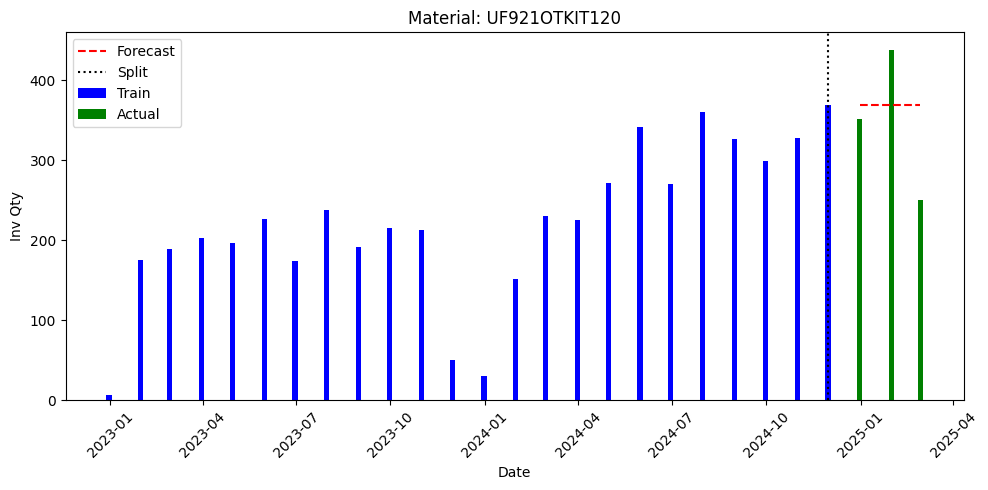

24 has  smape = 20.088385298054234
[{'Date': Timestamp('2024-12-31 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(352.0)}, {'Date': Timestamp('2025-01-31 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(438.0)}, {'Date': Timestamp('2025-02-28 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(250.0)}]
Fold RMSE: 139.48715592005843


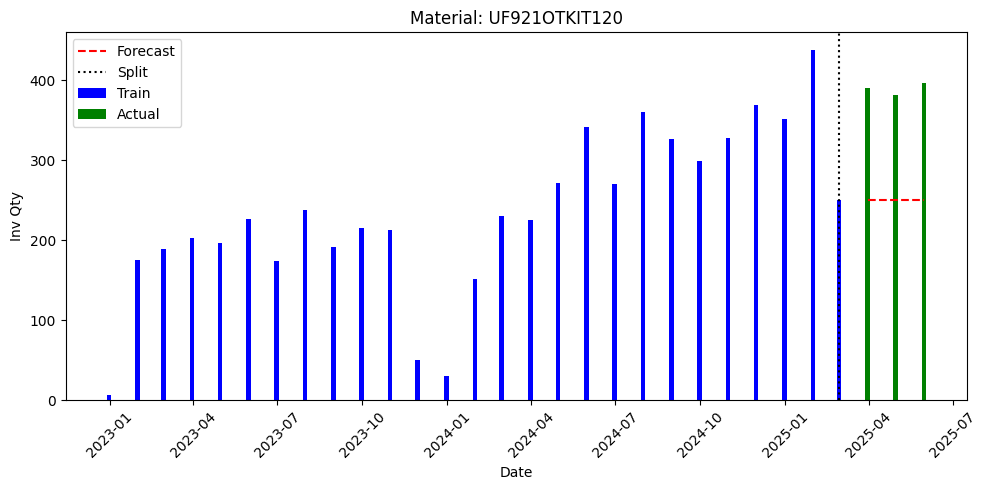

27 has  smape = 43.570629734048275
[{'Date': Timestamp('2024-12-31 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(352.0)}, {'Date': Timestamp('2025-01-31 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(438.0)}, {'Date': Timestamp('2025-02-28 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(250.0)}, {'Date': Timestamp('2025-03-31 00:00:00'), 'Predicted': np.float64(249.99999999999991), 'Actual': np.float64(390.0)}, {'Date': Timestamp('2025-04-30 00:00:00'), 'Predicted': np.float64(249.99999999999991), 'Actual': np.float64(381.0)}, {'Date': Timestamp('2025-05-31 00:00:00'), 'Predicted': np.float64(249.99999999999991), 'Actual': np.float64(397.0)}]
Fold RMSE: 151.89188558363645


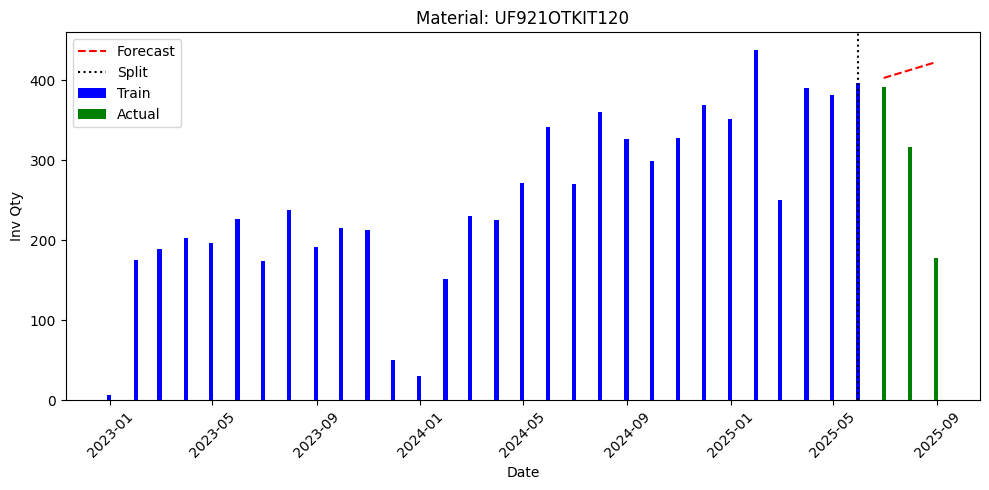

30 has  smape = 36.823086160874
[{'Date': Timestamp('2024-12-31 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(352.0)}, {'Date': Timestamp('2025-01-31 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(438.0)}, {'Date': Timestamp('2025-02-28 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(250.0)}, {'Date': Timestamp('2025-03-31 00:00:00'), 'Predicted': np.float64(249.99999999999991), 'Actual': np.float64(390.0)}, {'Date': Timestamp('2025-04-30 00:00:00'), 'Predicted': np.float64(249.99999999999991), 'Actual': np.float64(381.0)}, {'Date': Timestamp('2025-05-31 00:00:00'), 'Predicted': np.float64(249.99999999999991), 'Actual': np.float64(397.0)}, {'Date': Timestamp('2025-06-30 00:00:00'), 'Predicted': np.float64(402.8311550986616), 'Actual': np.float64(392.0)}, {'Date': Timestamp('2025-07-31 00:00:00'), 'Predicted': np.float64(412.81365355667424), 'Actual': np.float64(317.0)}, {'Date': Timestamp('2025-08-31 00:00:00'), 'Predicted': np.floa

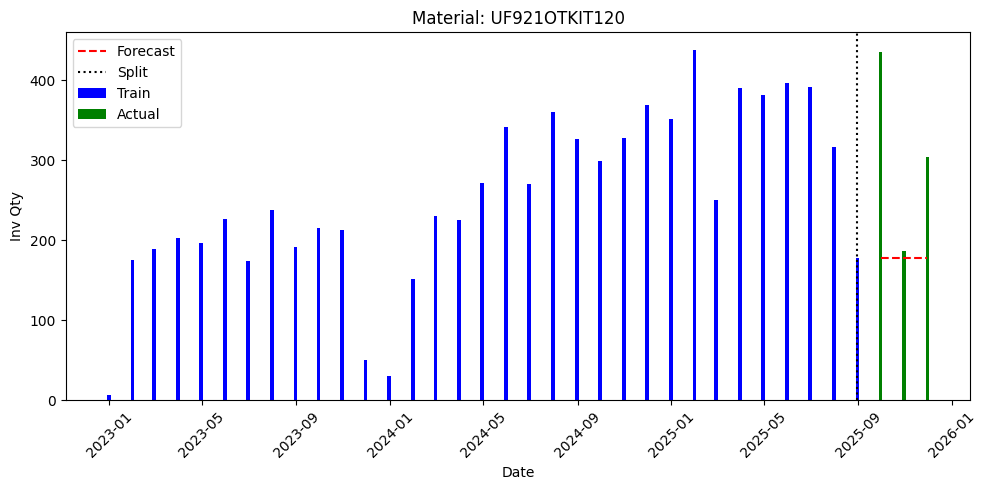

33 has  smape = 46.84256016862813
[{'Date': Timestamp('2024-12-31 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(352.0)}, {'Date': Timestamp('2025-01-31 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(438.0)}, {'Date': Timestamp('2025-02-28 00:00:00'), 'Predicted': np.float64(369.0), 'Actual': np.float64(250.0)}, {'Date': Timestamp('2025-03-31 00:00:00'), 'Predicted': np.float64(249.99999999999991), 'Actual': np.float64(390.0)}, {'Date': Timestamp('2025-04-30 00:00:00'), 'Predicted': np.float64(249.99999999999991), 'Actual': np.float64(381.0)}, {'Date': Timestamp('2025-05-31 00:00:00'), 'Predicted': np.float64(249.99999999999991), 'Actual': np.float64(397.0)}, {'Date': Timestamp('2025-06-30 00:00:00'), 'Predicted': np.float64(402.8311550986616), 'Actual': np.float64(392.0)}, {'Date': Timestamp('2025-07-31 00:00:00'), 'Predicted': np.float64(412.81365355667424), 'Actual': np.float64(317.0)}, {'Date': Timestamp('2025-08-31 00:00:00'), 'Predicted': np.fl

In [28]:
from scipy.stats import boxcox, yeojohnson
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from sklearn.preprocessing import PowerTransformer
from pmdarima import auto_arima
from arch.unitroot import PhillipsPerron




selected_materials = df_sorted['Master Mat']

selected_materials = selected_materials[0:10]

selected_materials = ['UF921OTKIT120']

for mat in selected_materials:
    temp = result_grouped[result_grouped['Master Mat'] == mat]
    
    if (temp['Inv. Qty'].sum() > 36) :
        # Aggregate by date (important if multiple entries per day)
        print(f"The total quantity is {temp['Inv. Qty'].sum()} \n")
        temp = temp.groupby('PO date')['Inv. Qty'].sum().reset_index()
            
        
        #Now create training and test for cross validation
        
        # Make the target variance stationary
        # temp['yeo johnson'], lam = yeojohnson(temp['Inv. Qty'])
    
        ts = temp.sort_values('PO date').set_index('PO date')['Inv. Qty']
        
        weekly_ts = ts.resample('W').sum().fillna(0)
        monthly_ts = ts.resample('ME').sum().fillna(0)
        ts = ts.resample('D').sum().fillna(0)
        
        pd.DataFrame(weekly_ts).to_excel("WeekData.xlsx", index=True)
        
        
        ts = monthly_ts
        print(ts)
        neg_rows = ts[ts < 0]
        print(neg_rows)

        
        result = adfuller(ts)
        print("p-value:", result[1])
        
        pp = PhillipsPerron(ts)

        print("Test Statistic:", pp.stat)
        print("p-value:", pp.pvalue)
        print("Critical Values:", pp.critical_values)
            
        
        train_weeks = 24
        test_weeks  = 3

        errors = []
        results =[]

        for end_train in range(train_weeks, len(ts) - test_weeks, test_weeks):

            train = ts.iloc[:end_train]
            test  = ts.iloc[end_train : end_train + test_weeks]


            pt = PowerTransformer(method='yeo-johnson')
            # pt = PowerTransformer(method='box-cox')
            train_transformed = pt.fit_transform(train.values.reshape(-1,1)).flatten()

            model = auto_arima(train_transformed, seasonal=False, stepwise=True, suppress_warnings=True)

            forecast_transformed = model.predict(n_periods=len(test))
            forecast = pt.inverse_transform(forecast_transformed.reshape(-1,1)).flatten()

            
            rmse = np.sqrt(np.mean((forecast - test.values)**2))
            errors.append(rmse)

            print(f"Fold RMSE: {rmse}")
            
            plt.figure(figsize=(10,5))

            plt.bar(train.index, train.values, label='Train', color='blue', width=5)
            plt.bar(test.index, test.values, label='Actual', color='green', width=5)
            plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--')

            plt.axvline(x=train.index[-1], color='black', linestyle=':', label='Split')

            plt.title(f"Material: {mat}")
            plt.xlabel("Date")
            plt.ylabel("Inv Qty")
            plt.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
            
            smape = np.mean(2 * np.abs(forecast - test.values) / (np.abs(test.values) + np.abs(forecast))) * 100
            print(f"{end_train} has  smape = {smape}")
            model.summary
            
            plt.savefig(f"forecast_{mat}_{end_train}.png")
            plt.close()
            
            for date, pred, actual in zip(test.index, forecast, test.values):
                results.append({
                    "Date": date,
                    "Predicted": pred,
                    "Actual": actual
                })

            print(results)
        
        pred_df = pd.DataFrame(results)
        
        pred_df["Month"] = pred_df["Date"].dt.to_period("M")

        monthly_df = pred_df.groupby("Month")[["Predicted", "Actual"]].sum().reset_index()
        
        monthly_df.to_excel("PredictedResults.xlsx" )
        print("Average RMSE:", np.mean(errors))
        print("Errors ", errors)
           
            
                
        # print(f"The value of lambda is {lam}")
        # plt.figure()
        # plt.bar(temp['PO date'], temp['yeo johnson'])
        # plt.axhline(0, color='black', linewidth=1)
        # plt.title(f"Material: {mat}")
        # plt.xlabel("PO Date")
        # plt.ylabel("Inventory Quantity")
        # plt.xticks(rotation=45)
        # plt.tight_layout()
        # plt.show()
        
        
        # # Difference the data
        # temp["yeo johnson diff"] = temp["yeo johnson"].diff()
        # temp.dropna(inplace=True)

        # # Plot acf and pacf
        # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,5), dpi=80)
        # plot_acf(temp['yeo johnson diff'])
        # plot_pacf(temp['yeo johnson diff'], method='ywm')
        # ax1.tick_params(axis='both', labelsize=10)
        # ax2.tick_params(axis='both', labelsize=10)
        # plt.show()
        
        
        

In [87]:
model.summary()




<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  152
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -193.469
Date:                Fri, 17 Apr 2026   AIC                            390.938
Time:                        19:50:37   BIC                            396.973
Sample:                             0   HQIC                           393.390
                                - 152                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8067      0.051    -15.717      0.000      -0.907      -0.706
sigma2         0.7540      0.070     10.744      0.000       0.616       0.892
===================================================================================
Ljung-Box (L1) (Q):                   0.65   Jarque-Bera (JB):                 9.77
Prob(Q):                              0.42   Prob(JB):                         0.01
Heteroskedasticity (H):               2.32   Skew:                             0.35
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [40]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 1.7 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.6 MB 2.6 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.6 MB 4.9 MB/s eta 0:00:02
   ------------------------------ --------- 7.3/9.6 MB 8.8 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 9.8 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [

In [ ]:


results = []
for mat in materials:
    temp = df[df["Material"] == mat]
    temp = temp.groupby('PO date')['Inv. Qty'].sum().reset_index()
    
    total_qty = temp['Inv. Qty'].sum()
    
    results.append({
        'Material': mat,
        'Total_Inv_Qty': total_qty,
        'Found' : mat in materials_ibm
    })

# Convert to DataFrame
result_df = pd.DataFrame(results)

# Export to Excel
result_df.to_excel('material_totals.xlsx', index=False)


    


The number of unique materials is 2240


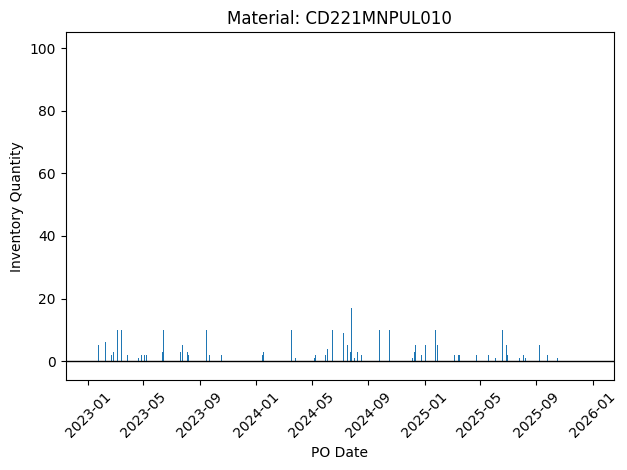

In [69]:
i, j = 0, 5   # example range
selected_materials = materials[i:j]
selected_materials = ["CD221MNPUL010"]

for mat in selected_materials:
    temp = df[df['Material'] == mat]
    
    # Aggregate by date (important if multiple entries per day)
    temp = temp.groupby('PO date')['Inv. Qty'].sum().reset_index()
    
    
    plt.figure()
    plt.bar(temp['PO date'], temp['Inv. Qty'])
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Material: {mat}")
    plt.xlabel("PO Date")
    plt.ylabel("Inventory Quantity")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:


print(f"The number of materials which is modelled by ibm is {len(materials_ibm)}")

print(df_ibm.columns)

The number of materials which is modelled by ibm is 1344
Index(['Plant', 'Material Code', 'Description', 'Pattern', 'Discontinued',
       'Year', 'Month', 'Model', 'Forecast', 'Actual', 'Accuracy %'],
      dtype='str')


In [ ]:
data['Month'] = pd.to_datetime(data['Month'])


def plot_passenger_volumes(df: pd.DataFrame,
                           y: str) -> None:
    """General function to plot the passenger data."""

    fig = px.line(df, x='Month', y=y, labels={'Month': 'Date'})
    fig.update_layout(template="simple_white", font=dict(size=18), title_text='Airline Passengers',
                      width=650, title_x=0.5, height=400)

    return fig.show()


# Plot the airline passenger data
plot_passenger_volumes(df=data, y='#Passengers')

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 3.9 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.9 MB 3.6 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.9 MB 3.9 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 4.4 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.9 MB 4.6 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 5.0 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 5.1 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 5.3 MB/s  0:00:01

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwha

In [20]:
%pip install arch

   ---------------------------------------- 0.0/934.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/934.4 kB ? eta -:--:--
   ---------------------------------------- 934.4/934.4 kB 4.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install plotly
%pip install pandas 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

file_path1 = r'D:\work\ifb\kamal\gdc\data\gdc_material_monthly_data.csv'


# Read in the data
df_consumption = pd.read_csv(file_path1, header=0)



In [73]:
import pandas as pd

file_path2 = r'D:\work\ifb\kamal\gdc\data\gdc_materials.csv'

# Adding explicit encoding and engine fixes standard local windows glitches
df_Mat = pd.read_csv(file_path2, header=0, encoding='latin1')

In [70]:

df_consumption

,material_code,year,month,consumption
0,UF321ECECB450,2024,4,0
1,UF321ECECB450,2024,5,0
2,UF321ECECB450,2024,6,0
3,UF321ECECB450,2024,7,0
4,UF321ECECB450,2024,8,0
...,...,...,...,...
995,UF221ECPBD160,2025,3,0
996,UF221ECPBD160,2025,4,0
997,UF221ECPBD160,2025,5,0
998,UF221ECPBD160,2025,6,1


In [74]:
sorted_parts = df_Mat[['material_code', 'lead_time', 'delta', 'req_on_12m_avg']].sort_values(by='req_on_12m_avg', 
    ascending=False)

In [66]:
sorted_parts

,material_code,lead_time,delta,req_on_12m_avg
17,TL221ECPCB040,90,15,327.333333
269,UF221ECPCB280,90,15,296.583333
239,TL221ECPBD040,90,15,295.833333
224,TL221ECPBD050,90,15,271.500000
18,TL221ECPCB130,90,15,270.666667
...,...,...,...,...
42,UF221ECEPB980,30,5,0.000000
49,TL221ECPBD370,90,15,0.000000
48,UF321ECEPB030,90,15,0.000000
47,UF321ECECB490,30,5,0.000000


In [77]:
df_consumption.query("material_code=='TL221ECPCB040'")
# sorted_parts

,material_code,year,month,consumption
5496,TL221ECPCB040,2024,4,118
5497,TL221ECPCB040,2024,5,120
5498,TL221ECPCB040,2024,6,303
5499,TL221ECPCB040,2024,7,538
5500,TL221ECPCB040,2024,8,916
5501,TL221ECPCB040,2024,9,860
5502,TL221ECPCB040,2024,10,567
5503,TL221ECPCB040,2024,11,337
5504,TL221ECPCB040,2024,12,291
5505,TL221ECPCB040,2025,1,169


In [78]:
merged_df = pd.merge( 
    df_consumption,         # The right dataframe (consumption data)
    sorted_parts,           # The left dataframe
    left_on='material_code',# The matching key in sorted_parts
    right_on='material_code',    # The matching key in your consumption excel
    how='left'              # Keep all records from sorted_parts, match what exists in consumption
)

In [104]:
res = merged_df.query("material_code =='TL221ECPCB040'")
res[['year', 'month']]

res['period'] = pd.to_datetime(res[['year', 'month']].assign(day=1)) #.dt.strftime('%m-%Y')

In [112]:
res['consumption']

5496    118
5497    120
5498    303
5499    538
5500    916
5501    860
5502    567
5503    337
5504    291
5505    169
5506    219
5507    119
5508    114
5509    119
5510    210
5511    461
5512    542
5513    608
5514    475
5515    393
5516    230
5517    271
5518    291
5519    214
Name: consumption, dtype: int64

In [83]:
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing

# ==========================================
# 1. DOUBLE EXPONENTIAL SMOOTHING FUNCTION
# ==========================================
def forecast_double_smoothing(series, forecast_steps=3):
    """
    Suitable for parts with a visible upward or downward trend 
    but no cyclical seasonality.
    """
    # Fit Holt's Linear Trend model
    model = Holt(series, initialization_method="estimated").fit()
    
    # Generate historical fitted values and out-of-sample forecast
    fitted_values = model.fittedvalues
    future_forecast = model.forecast(steps=forecast_steps)
    
    return fitted_values, future_forecast


# ==========================================
# 2. TRIPLE EXPONENTIAL SMOOTHING FUNCTION
# ==========================================
def forecast_triple_smoothing(series, seasonal_periods=12, forecast_steps=3):
    """
    Suitable for high-volume parts with both a trend and recurring seasonal cycles.
    use seasonal_periods=12 for monthly data, 4 for quarterly data.
    """
    # Fit Holt-Winters Exponential Smoothing model
    # Switching to multiplicative trend/seasonality if volume scales up with cycles
    model = ExponentialSmoothing(
        series, 
        trend="add", 
        seasonal="add", 
        seasonal_periods=seasonal_periods,
        initialization_method="estimated"
    ).fit()
    
    fitted_values = model.fittedvalues
    future_forecast = model.forecast(steps=forecast_steps)
    
    return fitted_values, future_forecast


# ==========================================
# 3. TSB (TEUNTER-SYNTETOS-BABAI) FUNCTION
# ==========================================
def forecast_tsb(series, alpha=0.2, beta=0.2, forecast_steps=3):
    """
    Industry standard for intermittent, lumpy, or slow-moving spare parts.
    Updates demand probability every period to capture sudden obsolescence.
    """
    y = np.asarray(series, dtype=float)
    n = len(y)
    
    z = np.zeros(n)  # Demand size component
    p = np.zeros(n)  # Demand probability component
    forecast = np.zeros(n + forecast_steps)
    
    # Initialize using non-zero elements
    non_zero = y[y > 0]
    z[0] = non_zero[0] if len(non_zero) > 0 else 0
    p[0] = len(non_zero) / n if n > 0 else 0
    forecast[0] = z[0] * p[0]
    
    # Historical timeline iteration
    for t in range(1, n):
        # Forecast for period t is determined by parameters calculated up to t-1
        forecast[t] = z[t-1] * p[t-1]
        
        # Update components with current period observation
        if y[t] > 0:
            z[t] = alpha * y[t] + (1 - alpha) * z[t-1]
            p[t] = beta * 1 + (1 - beta) * p[t-1]
        else:
            z[t] = z[t-1]
            p[t] = (1 - beta) * p[t-1]
            
    # Out-of-sample forecast (parameters remain static at the final horizon boundary)
    for h in range(0, forecast_steps):
        forecast[n + h] = z[-1] * p[-1]
        
    # Split historical vs future forecast to match statsmodels formatting
    fitted_values = pd.Series(forecast[:n], index=series.index)
    future_forecast = pd.Series(forecast[n:], index=pd.date_range(
        start=series.index[-1] + pd.offsets.MonthEnd(1), 
        periods=forecast_steps, 
        freq='ME'
    ))
    
    return fitted_values, future_forecast



In [109]:
start = res['period'].min().strftime('%m-%Y')
end = res['period'].max().strftime('%m-%Y')

print(start, end)
res['period']

04-2024 03-2026


5496   2024-04-01
5497   2024-05-01
5498   2024-06-01
5499   2024-07-01
5500   2024-08-01
5501   2024-09-01
5502   2024-10-01
5503   2024-11-01
5504   2024-12-01
5505   2025-01-01
5506   2025-02-01
5507   2025-03-01
5508   2025-04-01
5509   2025-05-01
5510   2025-06-01
5511   2025-07-01
5512   2025-08-01
5513   2025-09-01
5514   2025-10-01
5515   2025-11-01
5516   2025-12-01
5517   2026-01-01
5518   2026-02-01
5519   2026-03-01
Name: period, dtype: datetime64[us]

In [121]:

# ==========================================
# EXAMPLE EXECUTION WORKFLOW
# ==========================================

start = res['period'].min()
# 1. Simulating a sample intermittent/lumpy spare part history matching your layout
dates = res['period']
sample_consumption = res['consumption']

df_part = pd.DataFrame({
    'Consumption': sample_consumption
})

# 3. Assign the dates as the formal row index and sort it chronologically
df_part.index = dates
df_part = df_part.sort_index()

# 4. Give the index a clean name
df_part.index.name = 'Month-Year'

# 5. Print it directly (Do not wrap it in brackets!)
print("--- YOUR CLEAN TIME SERIES DATA ---")
print(df_part)





--- YOUR CLEAN TIME SERIES DATA ---
            Consumption
Month-Year             
2024-04-01          118
2024-05-01          120
2024-06-01          303
2024-07-01          538
2024-08-01          916
2024-09-01          860
2024-10-01          567
2024-11-01          337
2024-12-01          291
2025-01-01          169
2025-02-01          219
2025-03-01          119
2025-04-01          114
2025-05-01          119
2025-06-01          210
2025-07-01          461
2025-08-01          542
2025-09-01          608
2025-10-01          475
2025-11-01          393
2025-12-01          230
2026-01-01          271
2026-02-01          291
2026-03-01          214


In [125]:
%pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [127]:
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

# --- STEP 1: CHRONOLOGICAL TIME-SPLIT ---
# Assuming df_part has 24 months of data, we split at month 21
train_series = time_series_data.iloc[:-3]  # First 21 months (1 year, 9 months)
actual_test  = time_series_data.iloc[-3:]  # Last 3 months (The validation target)

HORIZON = len(actual_test)  # Dynamic horizon = 3 months

# --- STEP 2: GENERATE FORECASTS ON TRAIN DATA ---
# 1. Double Smoothing
_, fc_double = forecast_double_smoothing(train_series, forecast_steps=HORIZON)

# 2. Triple Smoothing (Using a shorter seasonal cycle like 3 or 4 if 12 is too long for a 21-month train set)
_, fc_triple = forecast_triple_smoothing(train_series, seasonal_periods=3, forecast_steps=HORIZON)

# 3. TSB Method
_, fc_tsb = forecast_tsb(train_series, alpha=0.2, beta=0.2, forecast_steps=HORIZON)


# --- STEP 3: ARRANGE RESULTS INTO A COMPARISON TABLE ---
# Ensure all forecasts match the exact timeline index of our actual test data
comparison_df = pd.DataFrame({
    'Actual_Demand': actual_test.values,
    'Double_Smooth': fc_double.values,
    'Triple_Smooth': fc_triple.values,
    'TSB_Method':    fc_tsb.values
}, index=actual_test.index)

print("--- HOLDOUT VALIDATION PREDICTIONS ---")
print(comparison_df)
print("\n" + "="*50 + "\n")


# --- STEP 4: CALCULATE ERROR METRICS ---
metrics = {}
for model_name in ['Double_Smooth', 'Triple_Smooth', 'TSB_Method']:
    rmse = root_mean_squared_error(comparison_df['Actual_Demand'], comparison_df[model_name])
    mae = mean_absolute_error(comparison_df['Actual_Demand'], comparison_df[model_name])
    metrics[model_name] = {'RMSE': round(rmse, 2), 'MAE': round(mae, 2)}

# Convert metrics dictionary to a clean summary DataFrame
df_errors = pd.DataFrame(metrics).T
print("--- MODEL ERROR METRICS ---")
print(df_errors)

# --- STEP 5: AUTOMATICALLY SELECT THE WINNER ---
best_model = df_errors['RMSE'].idxmin()
print(f"\n🏆 The best model for this specific spare part is: {best_model} (Lowest RMSE)")

--- HOLDOUT VALIDATION PREDICTIONS ---
            Actual_Demand  Double_Smooth  Triple_Smooth  TSB_Method
Month-Year                                                         
2026-01-01            271     235.599699     218.825854  366.300659
2026-02-01            291     241.199396     247.963572  366.300659
2026-03-01            214     246.799093     244.367307  366.300659


--- MODEL ERROR METRICS ---
                 RMSE     MAE
Double_Smooth   40.04   39.33
Triple_Smooth   42.80   41.86
TSB_Method     112.47  107.63

🏆 The best model for this specific spare part is: Double_Smooth (Lowest RMSE)


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
import numpy as np
import scipy.stats as stats

def paramCalc(lead_time, )
# --- YOUR CONTRACTUAL BOUNDARIES ---
min_lt = res['lead_time']
max_lt = res['lead_time'] + res['delta']

# Assume the most likely delivery time is the average of the two, 
# or use your domain knowledge (e.g., usually arrives in 85 days)
most_likely_lt = (min_lt + max_lt) / 2  # 92.5 days

# PERT distribution translates Min/Max/Mode into Beta distribution parameters (α, β)
shape_alpha = 1 + 4 * ((most_likely_lt - min_lt) / (max_lt - min_lt))
shape_beta = 1 + 4 * ((max_lt - most_likely_lt) / (max_lt - min_lt))

# inside your Monte Carlo simulation loop, you would draw lead times like this:
# simulated_lt = stats.beta.rvs(shape_alpha, shape_beta, loc=min_lt, scale=max_lt - min_lt)

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- STEP 1: DEFINE THE UNDERLYING MODELS (FROM EARLIER) ---

def forecast_double_smoothing(series, forecast_steps=3):
    model = Holt(series, initialization_method="estimated").fit()
    return model.forecast(steps=forecast_steps)

def forecast_triple_smoothing(series, seasonal_periods=3, forecast_steps=3):
    model = ExponentialSmoothing(series, trend="add", seasonal="add", 
                                 seasonal_periods=seasonal_periods, 
                                 initialization_method="estimated").fit()
    return model.forecast(steps=forecast_steps)

def forecast_tsb(series, alpha=0.2, beta=0.2, forecast_steps=3):
    y = np.asarray(series, dtype=float)
    n = len(y)
    z, p = np.zeros(n), np.zeros(n)
    forecast = np.zeros(n + forecast_steps)
    
    non_zero = y[y > 0]
    z[0] = non_zero[0] if len(non_zero) > 0 else 0
    p[0] = len(non_zero) / n if n > 0 else 0
    
    for t in range(1, n):
        if y[t] > 0:
            z[t] = alpha * y[t] + (1 - alpha) * z[t-1]
            p[t] = beta * 1 + (1 - beta) * p[t-1]
        else:
            z[t] = z[t-1]
            p[t] = (1 - beta) * p[t-1]
    for h in range(0, forecast_steps):
        forecast[n + h] = z[-1] * p[-1]
    return pd.Series(forecast[n:], index=pd.date_range(series.index[-1] + pd.offsets.MonthEnd(1), periods=forecast_steps, freq='ME'))


# --- STEP 2: RUN THE DYNAMIC HOLDOUT VALIDATION ---

# Create dummy 24-month dataset (Replace with your actual df_part['Consumption'])
dates = pd.date_range(start="2024-01-31", periods=24, freq="ME")
time_series_data = pd.Series([150, 0, 0, 180, 0, 0, 140, 0, 0, 110, 0, 0, 165, 0, 120, 0, 0, 0, 130, 0, 0, 145, 0, 0], index=dates)

# Dynamic Train/Test Split (Last 3 months held out)
train_series = time_series_data.iloc[:-3]
actual_test  = time_series_data.iloc[-3:]
HORIZON = len(actual_test)

# Generate predictions on the holdout slice
fc_double = forecast_double_smoothing(train_series, forecast_steps=HORIZON)
fc_triple = forecast_triple_smoothing(train_series, seasonal_periods=3, forecast_steps=HORIZON)
fc_tsb    = forecast_tsb(train_series, alpha=0.2, beta=0.2, forecast_steps=HORIZON)

# Calculate RMSE to find the winner
errors = {
    'Double_Smooth': root_mean_squared_error(actual_test, fc_double, squared=False),
    'Triple_Smooth': root_mean_squared_error(actual_test, fc_triple, squared=False),
    'TSB_Method':    root_mean_squared_error(actual_test, fc_tsb, squared=False)
}
winning_model_name = min(errors, key=errors.get)
print(f"🏆 Validation Winner: {winning_model_name} (Lowest RMSE)")


# --- STEP 3: GENERATE THE TRUE FUTURE FORECAST ---

# Re-train the winning model on ALL 24 months of data to project into the real future
if winning_model_name == 'Double_Smooth':
    future_forecast = forecast_double_smoothing(time_series_data, forecast_steps=3)
elif winning_model_name == 'Triple_Smooth':
    future_forecast = forecast_triple_smoothing(time_series_data, seasonal_periods=3, forecast_steps=3)
else:
    future_forecast = forecast_tsb(time_series_data, alpha=0.2, beta=0.2, forecast_steps=3)

# Calculate the Average Monthly Demand from our future forecast
avg_future_monthly_demand = future_forecast.mean()
print(f"Projected Future Demand: {avg_future_monthly_demand:.2f} units/month")


# --- STEP 4: THE MONTE CARLO MARRIAGE ENGINE ---

# Convert monthly demand to daily demand (assuming 30-day month)
mean_daily_demand = avg_future_monthly_demand / 30

# Calculate the Standard Deviation of our model's residuals to act as our demand uncertainty
# (This represents how much the model typically misses by)
if winning_model_name == 'Double_Smooth':
    residuals = time_series_data - Holt(time_series_data).fit().fittedvalues
else:
    residuals = time_series_data - time_series_data.mean() # Fallback variance proxy
std_daily_demand = residuals.std() / np.sqrt(30)


min_lt = res['lead_time']
max_lt = res['lead_time'] + res['delta']

# Assume the most likely delivery time is the average of the two, 
# or use your domain knowledge (e.g., usually arrives in 85 days)
most_likely_lt = (min_lt + max_lt) / 2  # 92.5 days

# PERT distribution translates Min/Max/Mode into Beta distribution parameters (α, β)
shape_alpha = 1 + 4 * ((most_likely_lt - min_lt) / (max_lt - min_lt))
shape_beta = 1 + 4 * ((max_lt - most_likely_lt) / (max_lt - min_lt))

# Define your Shifted Gamma Lead Time Parameters (Mean = 90 days, Max = 105 days)
# shape_k = 5.44
# scale_theta = 1.84
# loc_shift = 80.0  # Absolute minimum physical lead time fallback

# Run 10,000 simulated supplier replenishment cycles
simulations = 10000
ltd_distributions = []

for _ in range(simulations):
    # 1. Pull a random delivery timeline from the Gamma distribution
    # simulated_lt = stats.gamma.rvs(a=shape_k, loc=loc_shift, scale=scale_theta)
    simulated_lt = stats.beta.rvs(shape_alpha, shape_beta, loc=min_lt, scale=max_lt - min_lt)
    
    # 2. Simulate parts consumption during that specific delivery window
    total_demand = np.random.normal(
        loc = mean_daily_demand * simulated_lt, 
        scale = max(0.1, std_daily_demand * np.sqrt(simulated_lt))
    )
    ltd_distributions.append(max(0, total_demand))

df_ltd = pd.Series(ltd_distributions)


# --- STEP 5: EXTRACT THE INVENTORY DECISIONS ---

average_ltd = df_ltd.mean()
reorder_point_95 = df_ltd.quantile(0.95) # 95% availability target
safety_stock_95 = reorder_point_95 - average_ltd

print("\n" + "="*40 + "\n--- FINAL INVENTORY REPLENISHMENT PLAN ---")
print(f"Expected Demand During Lead Time: {average_ltd:.1f} units")
print(f"Safety Stock Buffer Required:     {safety_stock_95:.1f} units")
print(f"👉 REORDER POINT (ROP):           {reorder_point_95:.1f} units")
print(f"Action: Reorder when stock hits {int(np.ceil(reorder_point_95))} units to protect against supplier delays.")

,material_code,year,month,consumption,lead_time,delta,req_on_12m_avg,period
5496,TL221ECPCB040,2024,4,118,90,15,327.333333,2024-04-01
5497,TL221ECPCB040,2024,5,120,90,15,327.333333,2024-05-01
5498,TL221ECPCB040,2024,6,303,90,15,327.333333,2024-06-01
5499,TL221ECPCB040,2024,7,538,90,15,327.333333,2024-07-01
5500,TL221ECPCB040,2024,8,916,90,15,327.333333,2024-08-01
5501,TL221ECPCB040,2024,9,860,90,15,327.333333,2024-09-01
5502,TL221ECPCB040,2024,10,567,90,15,327.333333,2024-10-01
5503,TL221ECPCB040,2024,11,337,90,15,327.333333,2024-11-01
5504,TL221ECPCB040,2024,12,291,90,15,327.333333,2024-12-01
5505,TL221ECPCB040,2025,1,169,90,15,327.333333,2025-01-01
